# Smart Logistics Machine Learning 
* Rahim Manji

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv(
    '../data/smart_logistics_cleaned.csv',
    parse_dates=['Timestamp']
)

## Machine Learning Objective

The objective of this analysis is to develop a classification model that
predicts whether a logistics observation will experience a delay.

**Target Variable:** Logistics_Delay

- 0 = No Delay
- 1 = Delay

Models will be evaluated using multiple classification metrics, including
accuracy, precision, recall, F1-score, and ROC-AUC.

Variables that would reveal information unavailable at prediction time will
be excluded to prevent target leakage.

#### Recreate Engineering Features (from EDA)
- Inventory_Gap
- Month
- Day_of_Week

In [2]:
# Time-based features
data['Month'] = data['Timestamp'].dt.month
data['Day_of_Week'] = data['Timestamp'].dt.day_name()
data['Hour'] = data['Timestamp'].dt.hour
data['Is_Weekend'] = (data['Timestamp'].dt.dayofweek >= 5).astype(int)

# Inventory-related features
data['Inventory_Gap'] = (
    data['Inventory_Level'] - data['Demand_Forecast']
)

data['Inventory_Shortage'] = (
    data['Inventory_Gap'] < 0
).astype(int)

In [3]:
data.head()

,Timestamp,Asset_ID,Latitude,Longitude,Inventory_Level,Shipment_Status,Temperature,Humidity,Traffic_Status,Waiting_Time,...,Logistics_Delay_Reason,Asset_Utilization,Demand_Forecast,Logistics_Delay,Month,Day_of_Week,Hour,Is_Weekend,Inventory_Gap,Inventory_Shortage
0,2024-03-20 00:11:14,Truck_7,-65.7383,11.2497,390,Delayed,27.0,67.8,Detour,38,...,Unknown,60.1,285,1,3,Wednesday,0,0,105,0
1,2024-10-30 07:53:51,Truck_6,22.2748,-131.7086,491,In Transit,22.5,54.3,Heavy,16,...,Weather,80.9,174,1,10,Wednesday,7,0,317,0
2,2024-07-29 18:42:48,Truck_10,54.9232,79.5455,190,In Transit,25.2,62.2,Detour,34,...,Unknown,99.2,260,0,7,Monday,18,0,-70,1
3,2024-10-28 00:50:54,Truck_9,42.3900,-1.4788,330,Delivered,25.4,52.3,Heavy,37,...,Traffic,97.4,160,1,10,Monday,0,0,170,0
4,2024-09-27 15:52:58,Truck_7,-65.8477,47.9468,480,Delayed,20.5,57.2,Clear,56,...,Unknown,71.6,270,1,9,Friday,15,0,210,0


In [4]:
data.columns

Index(['Timestamp', 'Asset_ID', 'Latitude', 'Longitude', 'Inventory_Level',
       'Shipment_Status', 'Temperature', 'Humidity', 'Traffic_Status',
       'Waiting_Time', 'User_Transaction_Amount', 'User_Purchase_Frequency',
       'Logistics_Delay_Reason', 'Asset_Utilization', 'Demand_Forecast',
       'Logistics_Delay', 'Month', 'Day_of_Week', 'Hour', 'Is_Weekend',
       'Inventory_Gap', 'Inventory_Shortage'],
      dtype='object')

In [5]:
features = [
    'Asset_ID',
    'Inventory_Level',
    'Temperature',
    'Humidity',
    'Traffic_Status',
    'Waiting_Time',
    'User_Transaction_Amount',
    'User_Purchase_Frequency',
    'Asset_Utilization',
    'Demand_Forecast',
    'Inventory_Gap',
    'Inventory_Shortage',
    'Month',
    'Day_of_Week',
    'Hour',
    'Is_Weekend'
]

X = data[features]

y = data['Logistics_Delay']

In [6]:
print("Feature matrix:", X.shape)
print("Target:", y.shape)

X.head()

Feature matrix: (1000, 16)
Target: (1000,)


,Asset_ID,Inventory_Level,Temperature,Humidity,Traffic_Status,Waiting_Time,User_Transaction_Amount,User_Purchase_Frequency,Asset_Utilization,Demand_Forecast,Inventory_Gap,Inventory_Shortage,Month,Day_of_Week,Hour,Is_Weekend
0,Truck_7,390,27.0,67.8,Detour,38,320,4,60.1,285,105,0,3,Wednesday,0,0
1,Truck_6,491,22.5,54.3,Heavy,16,439,7,80.9,174,317,0,10,Wednesday,7,0
2,Truck_10,190,25.2,62.2,Detour,34,355,3,99.2,260,-70,1,7,Monday,18,0
3,Truck_9,330,25.4,52.3,Heavy,37,227,5,97.4,160,170,0,10,Monday,0,0
4,Truck_7,480,20.5,57.2,Clear,56,197,6,71.6,270,210,0,9,Friday,15,0


In [7]:
# Consider which variables we could use for predicting 
# Considerations to Categorical for ML

## Train/Test Split

The dataset is divided into training and testing sets. The training set is
used to develop the machine learning models, while the test set is held aside
to evaluate how well the models generalize to previously unseen observations.

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
# 20/80 split (20% in test)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [10]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (800, 16)
X_test: (200, 16)
y_train: (800,)
y_test: (200,)


In [11]:
# Maintain same distribution of delays and no_delays in both splits 

#stratify = y
#stratify

In [12]:
print("Training target distribution:")
print((y_train.value_counts(normalize=True) * 100).round(1))

print("\nTesting target distribution:")
print((y_test.value_counts(normalize=True) * 100).round(1))

Training target distribution:
Logistics_Delay
1    56.6
0    43.4
Name: proportion, dtype: float64

Testing target distribution:
Logistics_Delay
1    56.5
0    43.5
Name: proportion, dtype: float64


## Data Preprocessing

- Numerical and categorical features require different preprocessing steps.
- Numerical features are standardized
- Categorical features are converted to numerical representations using one-hot encoding.

- Preprocessing is performed within a scikit-learn pipeline to prevent information from the test set from influencing model training. (No Peaking)

Separate numerical and categorical features

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Timestamp                1000 non-null   datetime64[ns]
 1   Asset_ID                 1000 non-null   object        
 2   Latitude                 1000 non-null   float64       
 3   Longitude                1000 non-null   float64       
 4   Inventory_Level          1000 non-null   int64         
 5   Shipment_Status          1000 non-null   object        
 6   Temperature              1000 non-null   float64       
 7   Humidity                 1000 non-null   float64       
 8   Traffic_Status           1000 non-null   object        
 9   Waiting_Time             1000 non-null   int64         
 10  User_Transaction_Amount  1000 non-null   int64         
 11  User_Purchase_Frequency  1000 non-null   int64         
 12  Logistics_Delay_Reason   1000 non-n

In [14]:
numerical_features = [
    'Inventory_Level',
    'Temperature',
    'Humidity',
    'Waiting_Time',
    'User_Transaction_Amount',
    'User_Purchase_Frequency',
    'Asset_Utilization',
    'Demand_Forecast',
    'Inventory_Gap',
    'Inventory_Shortage',
    'Month',
    'Hour',
    'Is_Weekend'
]

categorical_features = [
    'Asset_ID',
    'Traffic_Status',
    'Day_of_Week'
]

In [15]:
print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))
print("Total features:", len(numerical_features) + len(categorical_features))

Numerical features: 13
Categorical features: 3
Total features: 16


Import our preprocessing tools

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

Differences in scale can affect how the model learns.
- StandardScaler can scale all numeric variables to Mean 0 and STD 1

In [17]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numerical_features
        ),
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        )
    ]
)

- One-hot encoding converts categories into binary indicators
- Incase the training set somehow doesn't contain a category that later appears in the test set.
- Without this setting, the encoder could throw an error.

In [18]:
OneHotEncoder(handle_unknown='ignore')

,categories,'auto'
,drop,None
,sparse_output,True
,dtype,<class 'numpy.float64'>
,handle_unknown,'ignore'
,min_frequency,None
,max_categories,None
,feature_name_combiner,'concat'


#### Baseline 
- the dataset has 1000 observations and is has ** 56.6% Delay and 46.4% No_Delay
-  need to be better than the above ^
-  Just by our dataset, if it picked Delay for everything, it would be correct 56.6% of the time

##  Baseline Model

- A Dummy Classifier is used to establish baseline performance.
- The baseline predicts the most frequent target class without learning relationships between
the predictor variables and logistics delays.

Subsequent machine learning models should outperform this baseline to
demonstrate meaningful predictive value.

In [19]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [20]:
#Train
baseline_model = DummyClassifier(
    strategy='most_frequent'
)

In [21]:
baseline_model.fit(X_train, y_train)

,strategy,'most_frequent'
,random_state,None
,constant,None


In [22]:
baseline_predictions = baseline_model.predict(X_test)

In [23]:
baseline_probabilities = baseline_model.predict_proba(X_test)[:, 1]

In [24]:
# Evaluate

baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

baseline_precision = precision_score(
    y_test,
    baseline_predictions
)

baseline_recall = recall_score(
    y_test,
    baseline_predictions
)

baseline_f1 = f1_score(
    y_test,
    baseline_predictions
)

baseline_roc_auc = roc_auc_score(
    y_test,
    baseline_probabilities
)

In [25]:
print(f"Accuracy:  {baseline_accuracy:.3f}")
print(f"Precision: {baseline_precision:.3f}")
print(f"Recall:    {baseline_recall:.3f}")
print(f"F1 Score:  {baseline_f1:.3f}")
print(f"ROC-AUC:   {baseline_roc_auc:.3f}")

Accuracy:  0.565
Precision: 0.565
Recall:    1.000
F1 Score:  0.722
ROC-AUC:   0.500


In [26]:
# ^ 56% as expected
# ROC 50% -> no ability to figure out if observation is delay or no_delay

##  Logistic Regression

- Logistic Regression is used as the first supervised classification model.
- Unlike the Dummy Classifier, Logistic Regression learns relationships between
the predictor variables and the probability of a logistics delay.

- Numerical scaling and categorical encoding are incorporated into a pipeline
to ensure that preprocessing is learned only from the training data.

### Build Pipeline
- Data
- ColumnTransfromer
- Numerical (standard scaler) / Categorical (OneHotEncoder)
- Logistic Regression
- Prediction

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [28]:
logistic_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

In [29]:
# Train

logistic_model.fit(
    X_train,
    y_train
)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [30]:
#Predict

logistic_predictions = logistic_model.predict(X_test)

logistic_probabilities = logistic_model.predict_proba(
    X_test
)[:, 1]

In [31]:
# Evaluate

logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

logistic_precision = precision_score(
    y_test,
    logistic_predictions
)

logistic_recall = recall_score(
    y_test,
    logistic_predictions
)

logistic_f1 = f1_score(
    y_test,
    logistic_predictions
)

logistic_roc_auc = roc_auc_score(
    y_test,
    logistic_probabilities
)

In [32]:
print(f"Accuracy:  {logistic_accuracy:.3f}")
print(f"Precision: {logistic_precision:.3f}")
print(f"Recall:    {logistic_recall:.3f}")
print(f"F1 Score:  {logistic_f1:.3f}")
print(f"ROC-AUC:   {logistic_roc_auc:.3f}")

Accuracy:  0.775
Precision: 0.925
Recall:    0.655
F1 Score:  0.767
ROC-AUC:   0.800


#### Metric	Logistic Regression	Interpretation

Accuracy	 77.5%	Correct on about 78% of test observations

Precision	92.5%	When it predicts a delay, it's usually correct

Recall	65.5%	It detects about 66% of actual delays

F1	76.7%	Reasonable precision/recall balance

ROC-AUC	0.800	Good ability to distinguish delay vs. no delay

When the model warns us that a shipment will be delayed, it is usually right. 
HOWEVER... it is still failing to identify roughly one-third of the shipments that actually experience delays

#### Confusion Matrix

In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [34]:
# calculate

logistic_cm = confusion_matrix(
    y_test,
    logistic_predictions
)

logistic_cm

array([[81,  6],
       [39, 74]])

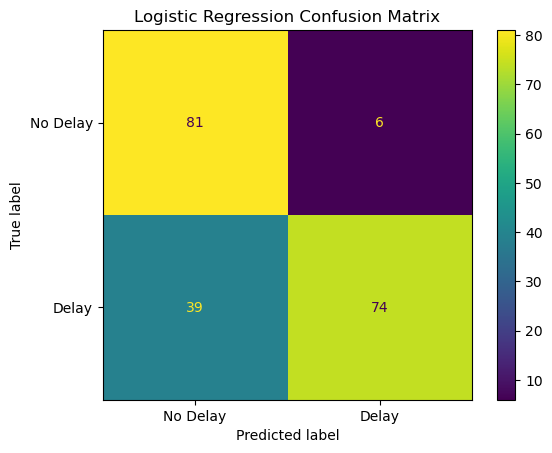

In [35]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=logistic_cm,
    display_labels=['No Delay', 'Delay']
)

disp.plot()

plt.title('Logistic Regression Confusion Matrix')
plt.show()

- 81 True Negatives: correctly identified no delay
- 74 True Positives: correctly identified delays
- 6 False Positives: unnecessary delay warnings
- 39 False Negatives: actual delays that the model missed

#### Model Interpretation: 
- Logistic Regression correctly classified 155 of 200 test observations (77.5%).
- The model produced only 6 false-positive delay warnings, resulting in high precision of 92.5%.
- However, it failed to identify 39 of the 113 actual delays, resulting in recall of 65.5%.
- This suggests that the model is relatively conservative when predicting delays.
- From an operational perspective, improving the detection of actual delays may be valuable even if doing so produces additional false-positive warnings.

## 6. Decision Tree

- A Decision Tree classifier is evaluated to capture nonlinear relationships
and interactions between operational variables. 
- Unlike Logistic Regression,
decision trees can create rule-based splits such as traffic conditions that
may strongly distinguish delayed from non-delayed observations.

In [36]:
from sklearn.tree import DecisionTreeClassifier

In [37]:
# Build
decision_tree_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(
            random_state=42
        ))
    ]
)

In [38]:
# Train
decision_tree_model.fit(
    X_train,
    y_train
)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [39]:
# Predict
tree_predictions = decision_tree_model.predict(X_test)

tree_probabilities = decision_tree_model.predict_proba(
    X_test
)[:, 1]

In [40]:
tree_accuracy = accuracy_score(y_test, tree_predictions)
tree_precision = precision_score(y_test, tree_predictions)
tree_recall = recall_score(y_test, tree_predictions)
tree_f1 = f1_score(y_test, tree_predictions)
tree_roc_auc = roc_auc_score(y_test, tree_probabilities)

print(f"Accuracy:  {tree_accuracy:.3f}")
print(f"Precision: {tree_precision:.3f}")
print(f"Recall:    {tree_recall:.3f}")
print(f"F1 Score:  {tree_f1:.3f}")
print(f"ROC-AUC:   {tree_roc_auc:.3f}")

Accuracy:  0.650
Precision: 0.694
Recall:    0.681
F1 Score:  0.688
ROC-AUC:   0.645


In [41]:
# Compare training and testing accuracy

tree_train_accuracy = decision_tree_model.score(
    X_train,
    y_train
)

tree_test_accuracy = decision_tree_model.score(
    X_test,
    y_test
)

print(f"Training Accuracy: {tree_train_accuracy:.3f}")
print(f"Testing Accuracy:  {tree_test_accuracy:.3f}")

Training Accuracy: 1.000
Testing Accuracy:  0.650


- Signs of OverFitting with 1.00

## Random Forest

A Random Forest classifier is evaluated to reduce the overfitting observed
in the individual Decision Tree. Random Forest combines predictions from
multiple decision trees trained on different samples and subsets of features,
which can improve generalization to unseen data.

In [42]:
from sklearn.ensemble import RandomForestClassifier

In [43]:
random_forest_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ))
    ]
)

In [44]:
random_forest_model.fit(
    X_train,
    y_train
)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [45]:
rf_predictions = random_forest_model.predict(X_test)

rf_probabilities = random_forest_model.predict_proba(
    X_test
)[:, 1]

In [46]:
rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_precision = precision_score(y_test, rf_predictions)
rf_recall = recall_score(y_test, rf_predictions)
rf_f1 = f1_score(y_test, rf_predictions)
rf_roc_auc = roc_auc_score(y_test, rf_probabilities)

print(f"Accuracy:  {rf_accuracy:.3f}")
print(f"Precision: {rf_precision:.3f}")
print(f"Recall:    {rf_recall:.3f}")
print(f"F1 Score:  {rf_f1:.3f}")
print(f"ROC-AUC:   {rf_roc_auc:.3f}")

Accuracy:  0.735
Precision: 0.885
Recall:    0.611
F1 Score:  0.723
ROC-AUC:   0.788


In [47]:
rf_train_accuracy = random_forest_model.score(
    X_train,
    y_train
)

rf_test_accuracy = random_forest_model.score(
    X_test,
    y_test
)

print(f"Training Accuracy: {rf_train_accuracy:.3f}")
print(f"Testing Accuracy:  {rf_test_accuracy:.3f}")

Training Accuracy: 1.000
Testing Accuracy:  0.735


##  Gradient Boosting

Gradient Boosting is evaluated as an additional ensemble method. Unlike
Random Forest, which combines independently constructed trees, Gradient
Boosting builds trees sequentially, with each new tree attempting to improve
errors made by the existing ensemble.

In [48]:
from sklearn.ensemble import GradientBoostingClassifier

In [49]:
gradient_boosting_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', GradientBoostingClassifier(
            random_state=42
        ))
    ]
)

In [50]:
gradient_boosting_model.fit(
    X_train,
    y_train
)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [51]:
gb_predictions = gradient_boosting_model.predict(X_test)

gb_probabilities = gradient_boosting_model.predict_proba(
    X_test
)[:, 1]


In [52]:
gb_accuracy = accuracy_score(y_test, gb_predictions)
gb_precision = precision_score(y_test, gb_predictions)
gb_recall = recall_score(y_test, gb_predictions)
gb_f1 = f1_score(y_test, gb_predictions)
gb_roc_auc = roc_auc_score(y_test, gb_probabilities)

print(f"Accuracy:  {gb_accuracy:.3f}")
print(f"Precision: {gb_precision:.3f}")
print(f"Recall:    {gb_recall:.3f}")
print(f"F1 Score:  {gb_f1:.3f}")
print(f"ROC-AUC:   {gb_roc_auc:.3f}")

Accuracy:  0.735
Precision: 0.866
Recall:    0.628
F1 Score:  0.728
ROC-AUC:   0.751


In [53]:
gb_train_accuracy = gradient_boosting_model.score(
    X_train,
    y_train
)

gb_test_accuracy = gradient_boosting_model.score(
    X_test,
    y_test
)

print(f"Training Accuracy: {gb_train_accuracy:.3f}")
print(f"Testing Accuracy:  {gb_test_accuracy:.3f}")

Training Accuracy: 0.902
Testing Accuracy:  0.735


## 9. Cross-Validation

Initial model evaluation used a held-out test set. To obtain a more robust
estimate of model performance and reduce reliance on a single train-test
split, stratified k-fold cross-validation is performed using only the
training data.

The test set remains excluded from this stage and will be reserved for final
model evaluation.

In [54]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

models = {
    'Logistic Regression': logistic_model,
    'Decision Tree': decision_tree_model,
    'Random Forest': random_forest_model,
    'Gradient Boosting': gradient_boosting_model
}

In [55]:
cv_results = []

for model_name, model in models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring
    )

    cv_results.append({
        'Model': model_name,
        'Accuracy': scores['test_accuracy'].mean(),
        'Precision': scores['test_precision'].mean(),
        'Recall': scores['test_recall'].mean(),
        'F1': scores['test_f1'].mean(),
        'ROC_AUC': scores['test_roc_auc'].mean()
    })

cv_results = pd.DataFrame(cv_results)

cv_results.round(3)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.728,0.861,0.618,0.719,0.769
1,Decision Tree,0.672,0.709,0.722,0.715,0.665
2,Random Forest,0.726,0.861,0.616,0.717,0.768
3,Gradient Boosting,0.734,0.833,0.662,0.737,0.779


## 10. Gradient Boosting Hyperparameter Tuning

Gradient Boosting produced the strongest overall cross-validation results.
Hyperparameter tuning is therefore performed using only the training data
to determine whether model generalization can be improved.

In [56]:
from sklearn.model_selection import GridSearchCV

In [57]:
param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__learning_rate': [0.05, 0.1],
    'classifier__max_depth': [1, 2, 3]
}

In [58]:
# 5 fold 18*5  90 fits 
grid_search = GridSearchCV(
    estimator=gradient_boosting_model,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1
)

grid_search.fit(
    X_train,
    y_train
)


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'classifier__learning_rate': [0.05, 0.1], 'classifier__max_depth': [1, 2, ...], 'classifier__n_estimators': [50, 100, ...]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [59]:
print("Best Parameters:")
print(grid_search.best_params_)

print(
    f"\nBest Cross-Validation ROC-AUC: "
    f"{grid_search.best_score_:.3f}"
)

Best Parameters:
{'classifier__learning_rate': 0.1, 'classifier__max_depth': 2, 'classifier__n_estimators': 50}

Best Cross-Validation ROC-AUC: 0.782


In [60]:
# best parameters

grid_search.best_params_

{'classifier__learning_rate': 0.1,
 'classifier__max_depth': 2,
 'classifier__n_estimators': 50}

In [61]:
# evaluate gradient boosting

best_gb_model = grid_search.best_estimator_

In [62]:
final_predictions = best_gb_model.predict(X_test)

final_probabilities = best_gb_model.predict_proba(
    X_test
)[:, 1]

In [63]:
final_accuracy = accuracy_score(
    y_test, final_predictions
)

final_precision = precision_score(
    y_test, final_predictions
)

final_recall = recall_score(
    y_test, final_predictions
)

final_f1 = f1_score(
    y_test, final_predictions
)

final_roc_auc = roc_auc_score(
    y_test, final_probabilities
)

print(f"Accuracy:  {final_accuracy:.3f}")
print(f"Precision: {final_precision:.3f}")
print(f"Recall:    {final_recall:.3f}")
print(f"F1 Score:  {final_f1:.3f}")
print(f"ROC-AUC:   {final_roc_auc:.3f}")

Accuracy:  0.750
Precision: 0.909
Recall:    0.619
F1 Score:  0.737
ROC-AUC:   0.746


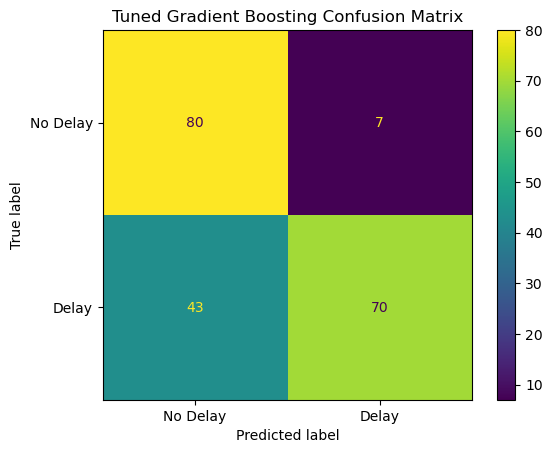

In [64]:
# confusion matrix

final_cm = confusion_matrix(
    y_test,
    final_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=final_cm,
    display_labels=['No Delay', 'Delay']
)

disp.plot()

plt.title('Tuned Gradient Boosting Confusion Matrix')
plt.show()

#### Extract feature importance from the tuned Gradient Boosting pipeline

In [65]:
# Get fitted preprocessing and classifier components

fitted_preprocessor = best_gb_model.named_steps['preprocessor']
fitted_classifier = best_gb_model.named_steps['classifier']

# Get transformed feature names
feature_names = fitted_preprocessor.get_feature_names_out()

# Get feature importances
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': fitted_classifier.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values('Importance', ascending=False)
    .reset_index(drop=True)
)

feature_importance.head(15)

,Feature,Importance
0,cat__Traffic_Status_Heavy,0.838845
1,num__Waiting_Time,0.037503
2,num__Temperature,0.021062
3,num__Asset_Utilization,0.020030
4,num__Demand_Forecast,0.019944
5,num__Inventory_Level,0.019038
6,num__Inventory_Gap,0.015374
7,num__Hour,0.011059
8,cat__Asset_ID_Truck_10,0.006195
9,num__Humidity,0.003942


In [67]:
# for optimization notebook 

import joblib

joblib.dump(
    best_gb_model,
    '../models/final_gradient_boosting_model.pkl'
)

['final_gradient_boosting_model.pkl']

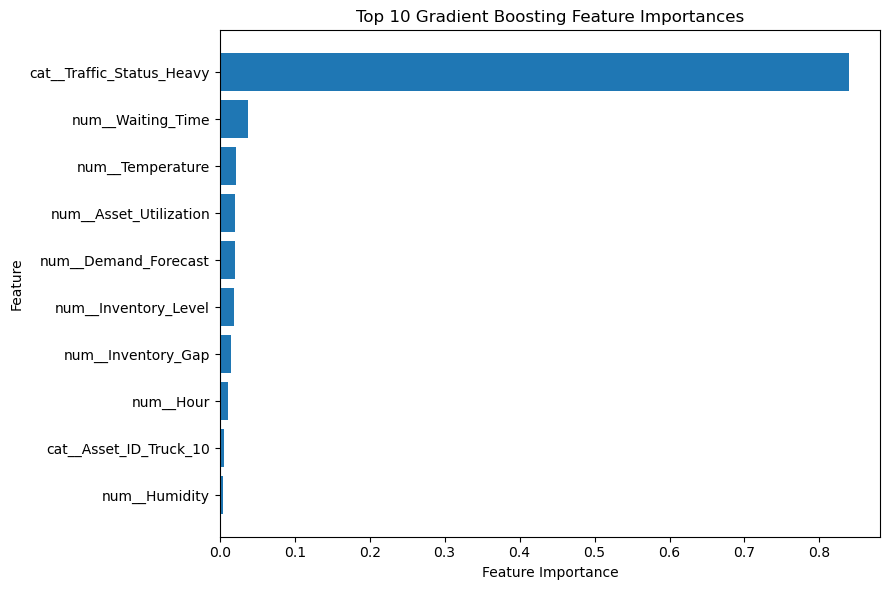

In [66]:
top_features = feature_importance.head(10).sort_values(
    'Importance'
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.title('Top 10 Gradient Boosting Feature Importances')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

## 11. Machine Learning Conclusions

Four classification algorithms were evaluated: Logistic Regression,
Decision Tree, Random Forest, and Gradient Boosting.

Five-fold stratified cross-validation showed that Gradient Boosting achieved
the strongest overall validation performance, with a mean ROC-AUC of 0.779.
Hyperparameter tuning produced a modest improvement to 0.782, using a
learning rate of 0.1, maximum tree depth of 2, and 50 estimators.

On the held-out test set, the tuned Gradient Boosting model achieved:

- Accuracy: 75.0%
- Precision: 90.9%
- Recall: 61.9%
- F1-score: 73.7%
- ROC-AUC: 0.746

Logistic Regression produced stronger performance on the single held-out
test set, including a ROC-AUC of 0.800, illustrating the importance of
evaluating models across multiple validation folds rather than relying on
a single train-test split.

Feature importance analysis showed that Heavy traffic overwhelmingly
dominated the Gradient Boosting model. This is consistent with the
exploratory analysis, where every Heavy-traffic observation was associated
with a logistics delay.

The deterministic relationship between Heavy traffic and delay, together
with other characteristics identified during exploratory analysis, suggests
that the dataset is likely synthetic. Model results should therefore be
interpreted as a demonstration of the machine-learning workflow rather than
as evidence that these relationships would generalize to a real logistics
operation.